# Pancreatic MatchMaker — Colab A100 Runner

Recommended: **clone this repo from GitHub** (see the **Load codebase** cell) — no zip on Google Drive, same commit you track in Git.

Optional: copy `results/` to Drive **after** training if you want persistence (the copy cell is off by default).

Pipeline:
1. Environment setup + checkout from **GitHub** (or legacy zip from Drive)
2. Dependencies
3. Data preprocessing (Bliss-variance filtering)
4. Split generation (LTO/LPO/LCO/LODO/LDO)
5. Training (`scripts/run_experiments.py`)
6. Report generation

Training defaults match the codebase: **min–max** (`--norm minmax`), **uniform** MSE weights unless you change knobs. Use `--norm tanh_norm` + `--weight-mode log` in the knobs cell only if you want the older baseline.

Use **Runtime → Change runtime type → GPU** before running.

In [35]:
# Quick file check — re-run AFTER the "Load codebase" cell (git clone or zip / %cd into ens_492)
from pathlib import Path

for name in ('helper_funcs.py', 'MatchMaker.py'):
    p = Path(name)
    print(name, 'OK' if p.exists() else 'MISSING — run checkout cell first')

hf = Path('helper_funcs.py')
if hf.exists():
    t = hf.read_text(encoding='utf-8', errors='replace')
    print('helper_funcs.py: minmax scaling path:', "minmax" in t and "'minmax'" in t)
mm = Path('MatchMaker.py')
if mm.exists():
    t = mm.read_text(encoding='utf-8', errors='replace')
    print('MatchMaker.py: TerminateOnNaN in trainer:', 'TerminateOnNaN' in t)

helper_funcs path: /content/matchmaker_test/helper_funcs.py
MatchMaker path: /content/matchmaker_test/MatchMaker.py


OSError: could not get source code

In [36]:
import shutil

# Cleanup before cloning (run once per fresh session).
shutil.rmtree("/content/matchmaker_test", ignore_errors=True)
print("Removed /content/matchmaker_test if it existed.")


removed old /content/matchmaker_test


In [37]:
# --- Load codebase: GitHub (recommended) OR zip on Drive (legacy) ---
import os
import shutil
import subprocess
import zipfile
from pathlib import Path

PROJECT_SOURCE = "github"  # "github" | "drive_zip"

# Public HTTPS URL. Private repo: token URL or Colab secrets —
# https://TOKEN@github.com/org/repo.git
GIT_REPO_URL = "https://github.com/YOUR_USERNAME_OR_ORG/YOUR_REPO.git"
GIT_BRANCH = "main"

DRIVE_ZIP_PATH = Path("/content/drive/MyDrive/matchmaker_test.zip")
CLONE_PARENT = Path("/content/matchmaker_test")

shutil.rmtree(CLONE_PARENT, ignore_errors=True)
WORKDIR = None

if PROJECT_SOURCE == "github":
    cmd = ["git", "clone", "--depth", "1", "--branch", GIT_BRANCH, GIT_REPO_URL, str(CLONE_PARENT)]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    if (CLONE_PARENT / "ens_492" / "main.py").exists():
        WORKDIR = CLONE_PARENT / "ens_492"
    elif (CLONE_PARENT / "main.py").exists():
        WORKDIR = CLONE_PARENT
    else:
        raise FileNotFoundError(
            "Clone OK but main.py not found at repo root or ens_492/. Fix GIT_REPO_URL or layout."
        )

elif PROJECT_SOURCE == "drive_zip":
    from google.colab import drive

    drive.mount("/content/drive")
    if not DRIVE_ZIP_PATH.exists():
        raise FileNotFoundError(f"Zip not found: {DRIVE_ZIP_PATH}")

    extr = Path("/content/_drive_zip_out")
    shutil.rmtree(extr, ignore_errors=True)
    extr.mkdir(parents=True)
    print("Extracting:", DRIVE_ZIP_PATH)
    with zipfile.ZipFile(DRIVE_ZIP_PATH) as zf:
        zf.extractall(extr)

    mains = list(extr.glob("**/main.py"))
    if not mains:
        raise ValueError("No main.py in zip.")
    pref = [m.parent for m in mains if m.parent.name == "ens_492"]
    if pref:
        WORKDIR = pref[0].resolve()
    else:
        WORKDIR = sorted((m.parent for m in mains), key=lambda p: len(str(p)))[0].resolve()

else:
    raise ValueError(f'PROJECT_SOURCE must be "github" or "drive_zip", got {PROJECT_SOURCE!r}')

os.chdir(WORKDIR)
os.environ["MATCHMAKER_ROOT"] = str(WORKDIR.resolve())
print("Working directory:", Path.cwd())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive output root: /content/drive/MyDrive/matchmaker_runs


In [38]:
# Unused placeholder (zip+DRIVE flow merged into previous cell).

pass



Extracting zip from Drive: /content/drive/MyDrive/matchmaker_test.zip
Detected project folder: /content/matchmaker_test
/content/matchmaker_test
/content/matchmaker_test
'2020.05.24.113241v3.full (1).pdf'   LICENSE
 architecture.txt		     main.py
 bitirme_meeting1.ipynb		     MatchMaker.py
 cell_line_gex_new.csv		     matchmaker_saved.h5
 colab_run_matchmaker.ipynb	     OHE_Bionformatics_Main_R2.pdf
 data				     performance_metrics.py
 drug2_chem.csv			     pred1.txt
 drugChemFeatParser.py		     preliminary.ipynb
 drug_chem_rdkit.csv		     __pycache__
 drug_chem_rdkit_noheader.csv	     README.md
 drug_ids_order.txt		     results
 drug_id_table.csv		     scripts
 drug_smiles.csv		     splits
 drug_smiles_with_ids.csv	     uniquq.ipynb
 helper_funcs.py		     y_test.txt


In [9]:
# Optional: debug Colab paths (ignore if `import tensorflow` next cell works)
!pwd

/content
drive  sample_data


In [39]:
# 2) Install dependencies
!python -m pip install -q --upgrade pip
!python -m pip install -q numpy pandas scipy scikit-learn tensorflow

import tensorflow as tf
print('TF version:', tf.__version__)
!nvidia-smi

TF version: 2.19.0
Fri Mar 27 00:12:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------

In [40]:
# 3) Configure experiment knobs
SEEDS = [42, 43, 44]
RUN_TRAINING = True   # set False to only test preprocessing/splits
GPU_DEVICES = '0'

# Classification threshold for converting regression score to class prediction
CLASSIFICATION_THRESHOLD = 0.0

# Raw data location (your uploaded pancreatic raw file)
RAW_CSV = 'data/synergy - comb - Combination data.csv'

# Training / preprocessing (passed to scripts/run_experiments.py -> main.py)
# Defaults: merged pipeline (Arda-style min-max + selectable weights).
NORM = 'minmax'   # alternatives: tanh_norm, norm, tanh
WEIGHT_MODE = 'uniform'   # uniform | q3_upweight | log
WEIGHT_ALPHA = 3.0   # q3_upweight only
LR = 1e-4
INPUT_DROPOUT = 0.2
DROPOUT = 0.5
BATCH_SIZE = 128
MAX_EPOCH = 1000
EARLYSTOP = 100

print('SEEDS:', SEEDS)
print('RUN_TRAINING:', RUN_TRAINING)
print('RAW_CSV:', RAW_CSV)
print('NORM:', NORM, '| WEIGHT_MODE:', WEIGHT_MODE, '| LR:', LR, '| BATCH_SIZE:', BATCH_SIZE)

# Backup to Drive (optional). Step 9 copies results/splits when SAVE_TO_DRIVE is True.
from pathlib import Path

SAVE_TO_DRIVE = False
DRIVE_BACKUP_ROOT = Path('/content/drive/MyDrive/matchmaker_runs')



SEEDS: [42, 43, 44]
RUN_TRAINING: True
RAW_CSV: data/synergy - comb - Combination data.csv


In [41]:
# 4) Step A - preprocess pancreatic data (writes unfiltered + Bliss-variance–filtered)
# Variance filter: IQR rule on replicate Bliss variance per (pair, cell) — same spirit as meeting4_dataprocessing.ipynb (without quartile class labels).
# Pure Python (no shell heredoc) — avoids NameError on stray `PY` in Colab/Cursor.
import os
import subprocess
import pandas as pd

subprocess.run(
    ['python', 'scripts/prepare_pancreatic_data.py', '--raw-csv', RAW_CSV, '--out-dir', 'data/processed'],
    check=True,
)
print('data/processed:', os.listdir('data/processed'))
print('unfiltered shape:', pd.read_csv('data/processed/pancreatic_unfiltered.tsv', sep='\t').shape)
print('variance_filtered shape:', pd.read_csv('data/processed/pancreatic_variance_filtered.tsv', sep='\t').shape)


data/processed: ['data_card.md', 'pancreatic_variance_filtered.tsv', 'pancreatic_unfiltered.tsv']
unfiltered shape: (9893, 9)
filtered shape: (3554, 9)


In [42]:
# 5) Step B - generate split files (LTO/LPO/LCO/LODO/LDO)
import json
import os
import subprocess

seed_args = [str(s) for s in SEEDS]
subprocess.run(
    ['python', 'scripts/generate_splits.py', '--input-tsv', 'data/processed/pancreatic_variance_filtered.tsv',
     '--outdir', 'splits', '--seeds'] + seed_args,
    check=True,
)
print('splits:', os.listdir('splits'))
with open('splits/leakage_report.json') as f:
    leak = json.load(f)
print('num leakage entries:', len(leak))
print('example:', leak[0])


splits: ['lpo', 'leakage_report.json', 'lco', 'lodo', 'lto', 'ldo']
num leakage entries: 15
example: {'pair_overlap': 260, 'drug_overlap': 57, 'cell_overlap': 30, 'n_train': 2276, 'n_test': 710, 'split': 'lto', 'seed': 42, 'folder': 'splits/lto/seed_42'}


In [43]:
# 6) Step C - optional dry run to verify command matrix
import subprocess

seed_args = [str(s) for s in SEEDS]
cmd = (
    ['python', 'scripts/run_experiments.py',
     '--project-root', '.', '--seeds'] + seed_args
    + ['--splits-root', 'splits',
       '--processed-root', 'data/processed',
       '--out-root', 'results/runs',
       '--gpu-devices', GPU_DEVICES,
       '--classification-threshold', str(CLASSIFICATION_THRESHOLD),
       '--norm', NORM,
       '--weight-mode', WEIGHT_MODE,
       '--weight-alpha', str(WEIGHT_ALPHA),
       '--lr', str(LR),
       '--input-dropout', str(INPUT_DROPOUT),
       '--dropout', str(DROPOUT),
       '--batch-size', str(BATCH_SIZE),
       '--max-epoch', str(MAX_EPOCH),
       '--earlystop', str(EARLYSTOP),
       '--dry-run']
)
subprocess.run(cmd, check=True)

[DRY RUN] python3 main.py --comb-data-name data/processed/pancreatic_unfiltered.tsv --label-column synergy_loewe --classification-label-column synergy_binary --classification-threshold 0.0 --train-ind splits/lto/seed_42/train_inds.txt --val-ind splits/lto/seed_42/val_inds.txt --test-ind splits/lto/seed_42/test_inds.txt --split-mode files --saved-model-name results/runs/unfiltered/lto/seed_42/matchmaker.h5 --outdir results/runs/unfiltered/lto/seed_42 --gpu-devices 0 --train-test-mode 1
[DRY RUN] python3 main.py --comb-data-name data/processed/pancreatic_unfiltered.tsv --label-column synergy_loewe --classification-label-column synergy_binary --classification-threshold 0.0 --train-ind splits/lto/seed_43/train_inds.txt --val-ind splits/lto/seed_43/val_inds.txt --test-ind splits/lto/seed_43/test_inds.txt --split-mode files --saved-model-name results/runs/unfiltered/lto/seed_43/matchmaker.h5 --outdir results/runs/unfiltered/lto/seed_43 --gpu-devices 0 --train-test-mode 1
[DRY RUN] python3 ma

In [44]:
# 7) Step D - full training matrix
# This runs: {unfiltered, filtered} x {lto,lpo,lco,lodo,ldo} x seeds
import subprocess

if RUN_TRAINING:
    seed_args = [str(s) for s in SEEDS]
    cmd = (
        ['python', 'scripts/run_experiments.py',
         '--project-root', '.', '--seeds'] + seed_args
        + ['--splits-root', 'splits',
           '--processed-root', 'data/processed',
           '--out-root', 'results/runs',
           '--gpu-devices', GPU_DEVICES,
           '--classification-threshold', str(CLASSIFICATION_THRESHOLD),
           '--norm', NORM,
           '--weight-mode', WEIGHT_MODE,
           '--weight-alpha', str(WEIGHT_ALPHA),
           '--lr', str(LR),
           '--input-dropout', str(INPUT_DROPOUT),
           '--dropout', str(DROPOUT),
           '--batch-size', str(BATCH_SIZE),
           '--max-epoch', str(MAX_EPOCH),
           '--earlystop', str(EARLYSTOP)]
    )
    subprocess.run(cmd, check=True)
else:
    print('RUN_TRAINING is False, skipping training.')

Running: python3 main.py --comb-data-name data/processed/pancreatic_unfiltered.tsv --label-column synergy_loewe --classification-label-column synergy_binary --classification-threshold 0.0 --train-ind splits/lto/seed_42/train_inds.txt --val-ind splits/lto/seed_42/val_inds.txt --test-ind splits/lto/seed_42/test_inds.txt --split-mode files --saved-model-name results/runs/unfiltered/lto/seed_42/matchmaker.h5 --outdir results/runs/unfiltered/lto/seed_42 --gpu-devices 0 --train-test-mode 1
2026-03-27 00:13:12.710084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774570392.731866   35641 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774570392.739077   35641 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for

In [45]:
# 8) Step E - build summary report
if RUN_TRAINING:
    !python scripts/build_report.py --summary-csv results/summary_metrics.csv --per-seed-csv results/per_split_seed_metrics.csv --out-md results/report.md
    !ls results
    !sed -n '1,120p' results/report.md
else:
    print('RUN_TRAINING is False, no report to build.')

Wrote stub report: results/report.md
Missing: results/summary_metrics.csv results/per_split_seed_metrics.csv
per_split_seed_metrics.csv  report.md  runs
# Pancreatic MatchMaker report

## Error

Missing input CSV(s). Training likely failed or did not finish.

- Expected: `results/summary_metrics.csv`
- Expected: `results/per_split_seed_metrics.csv`

Fix NaN labels / rerun training, then rebuild report.


In [ ]:
# 9) Optional: copy outputs to Drive (set SAVE_TO_DRIVE + RUN_TRAINING in knobs cell)
from pathlib import Path
import os
import shutil

ROOT = Path(os.environ.get("MATCHMAKER_ROOT", ".")).resolve()

if SAVE_TO_DRIVE and RUN_TRAINING:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_BACKUP_ROOT.mkdir(parents=True, exist_ok=True)
    tgt = DRIVE_BACKUP_ROOT / "results"
    if tgt.exists():
        shutil.rmtree(tgt)
    shutil.copytree(ROOT / "results", tgt)
    print("Copied results to", tgt)

    stgt = DRIVE_BACKUP_ROOT / "splits"
    if stgt.exists():
        shutil.rmtree(stgt)
    shutil.copytree(ROOT / "splits", stgt)
    print("Copied splits to", stgt)
else:
    print("Drive copy skipped.")


In [46]:
from pathlib import Path
import os
import shutil
import datetime

ROOT = Path(os.environ["MATCHMAKER_ROOT"])
src = ROOT / "results"
dst_root = Path("/content/drive/MyDrive/matchmaker_runs")
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
dst = dst_root / "results_backup_{}".format(stamp)

dst_root.mkdir(parents=True, exist_ok=True)
shutil.copytree(src, dst)
print("Backed up to:", dst)


Backed up to: /content/drive/MyDrive/matchmaker_runs/results_backup_20260327_011034


In [51]:
import os
from pathlib import Path
import pandas as pd
import subprocess
import sys

ROOT = Path(os.environ["MATCHMAKER_ROOT"])

root = ROOT / "results" / "runs"
rows = []

for p in root.glob("*/*/seed_*/results.csv"):
    dataset = p.parts[-4]
    split = p.parts[-3]
    seed = int(p.parts[-2].split("_")[1])
    df = pd.read_csv(p)
    rec = df.iloc[0].to_dict()
    rec.update({"dataset": dataset, "split": split, "seed": seed})
    rows.append(rec)

all_df = pd.DataFrame(rows)
outdir = ROOT / "results"
outdir.mkdir(parents=True, exist_ok=True)
all_df.to_csv(outdir / "per_split_seed_metrics.csv", index=False)

num_cols = all_df.select_dtypes(include="number").columns
summary = all_df.groupby(["dataset", "split"], as_index=False)[num_cols].agg(["mean", "std"])
summary.columns = ["{}_{}".format(a, b) if b else str(a) for a, b in summary.columns]
summary.to_csv(outdir / "summary_metrics.csv", index=False)

print("Wrote per_split_seed_metrics.csv and summary_metrics.csv")
subprocess.run([sys.executable, "scripts/build_report.py"], cwd=str(ROOT), check=True)


Wrote per_split_seed_metrics.csv and summary_metrics.csv
/content/matchmaker_test
Wrote: results/report.md


In [50]:
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path(os.environ["MATCHMAKER_ROOT"])
subprocess.run([sys.executable, "scripts/build_report.py"], cwd=str(ROOT), check=True)


/content/matchmaker_test
Wrote: results/report.md


In [ ]:
# OPTIONAL — bulk copy to Drive only when you need a manual backup bundle
import os
from pathlib import Path
import shutil
import datetime
import json

PROJECT = Path(os.environ["MATCHMAKER_ROOT"])
DRIVE_ROOT = Path("/content/drive/MyDrive/matchmaker_runs")

TO_COPY = [
    PROJECT / "results",
    PROJECT / "data/processed",
    PROJECT / "splits",
]

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
dst = DRIVE_ROOT / "matchmaker_outputs_{}".format(stamp)

from google.colab import drive

drive.mount("/content/drive")
dst.parent.mkdir(parents=True, exist_ok=True)
dst.mkdir(parents=True)

copied = []
for src in TO_COPY:
    if src.exists():
        target = dst / src.name
        shutil.copytree(src, target, dirs_exist_ok=True)
        copied.append(str(target))
    else:
        print("Skipped (not found):", src)

manifest = dst / "manifest.json"
manifest.write_text(json.dumps({"copied_paths": copied}, indent=2))
print("Saved outputs to:", dst)
print("Manifest:", manifest)


Saved outputs to: /content/drive/MyDrive/matchmaker_runs/matchmaker_outputs_20260327_011726
Manifest: /content/drive/MyDrive/matchmaker_runs/matchmaker_outputs_20260327_011726/manifest.json


/tmp/ipykernel_4354/1845776397.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["dataset", "split"])[metrics]


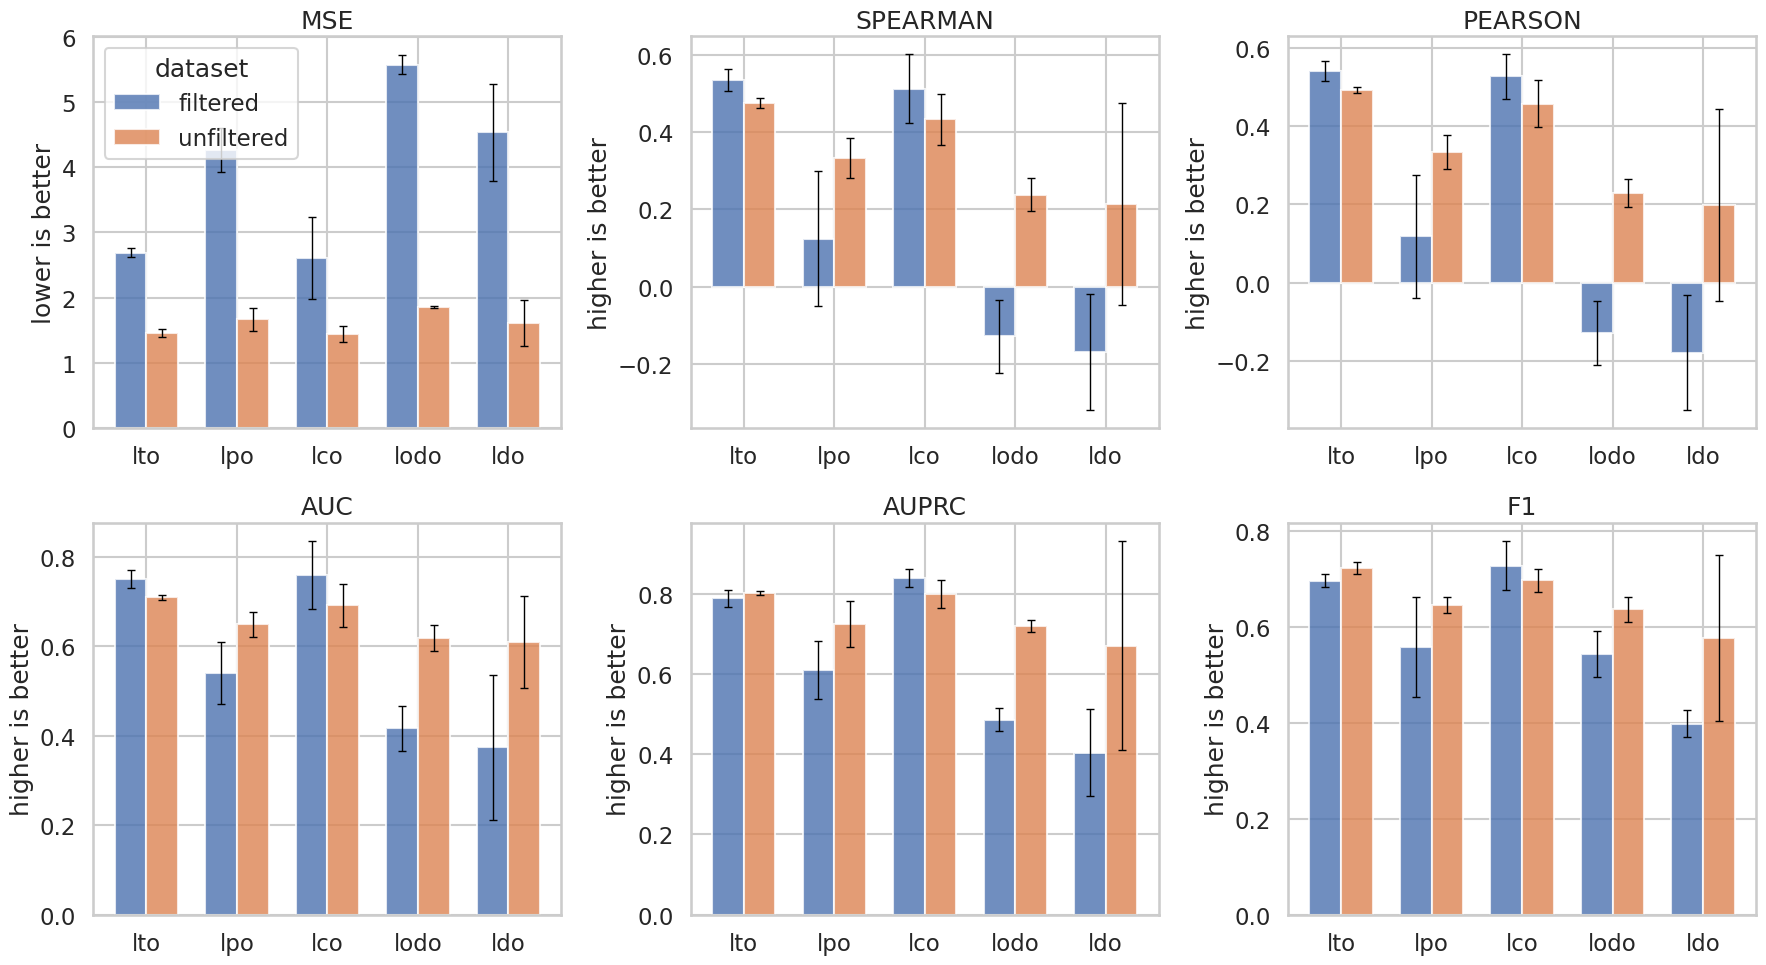

/tmp/ipykernel_4354/1845776397.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("split")[metrics]


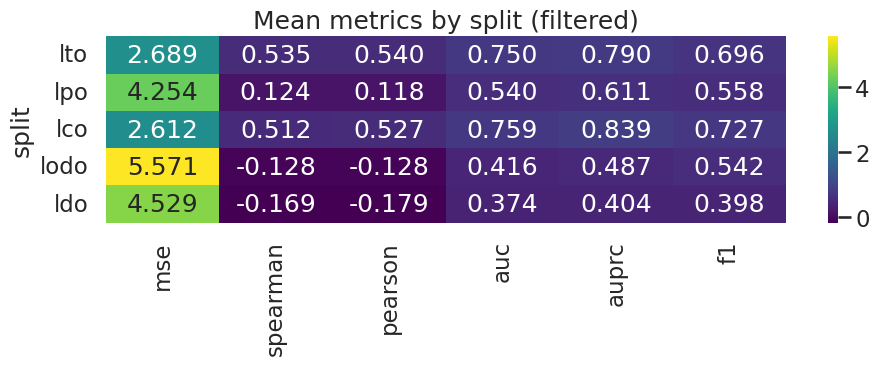

/tmp/ipykernel_4354/1845776397.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("split")[metrics]


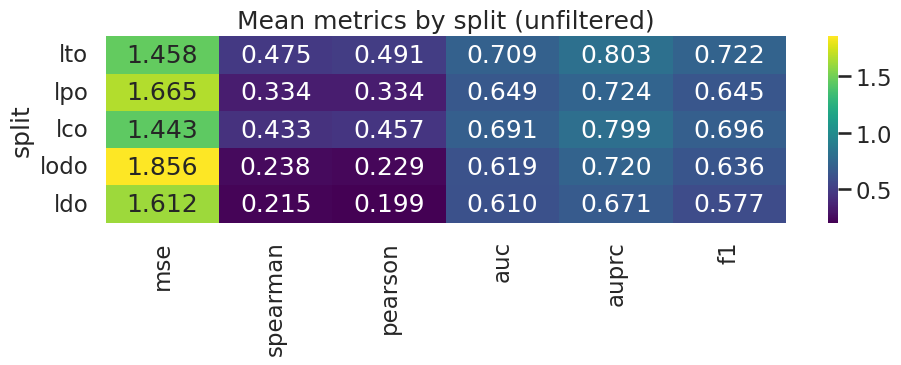

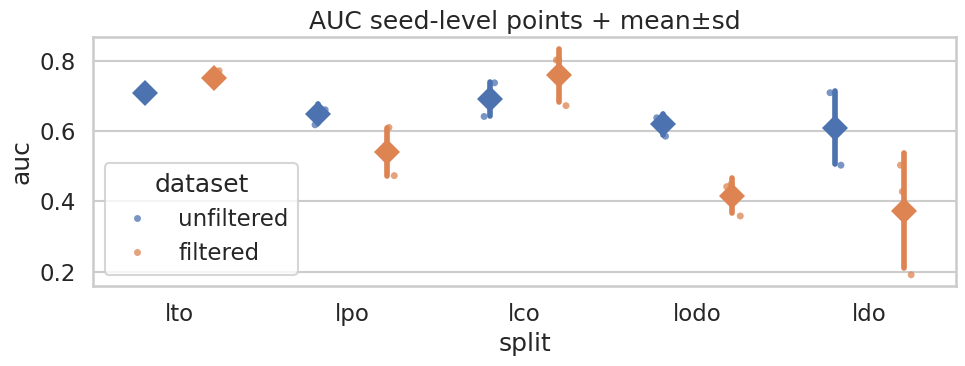

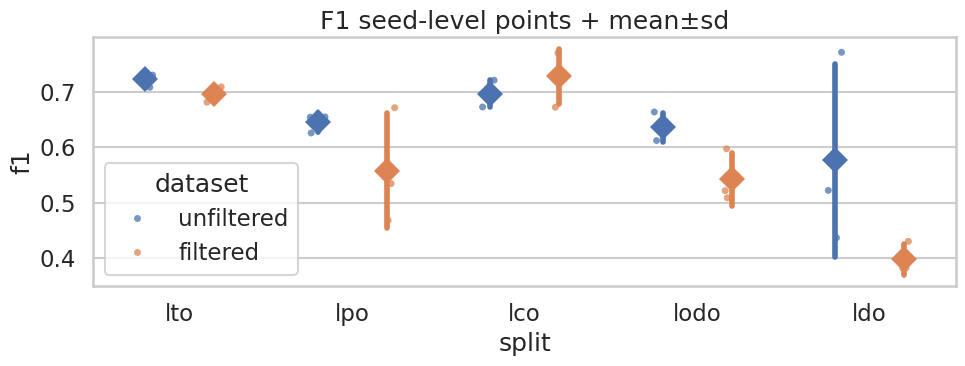

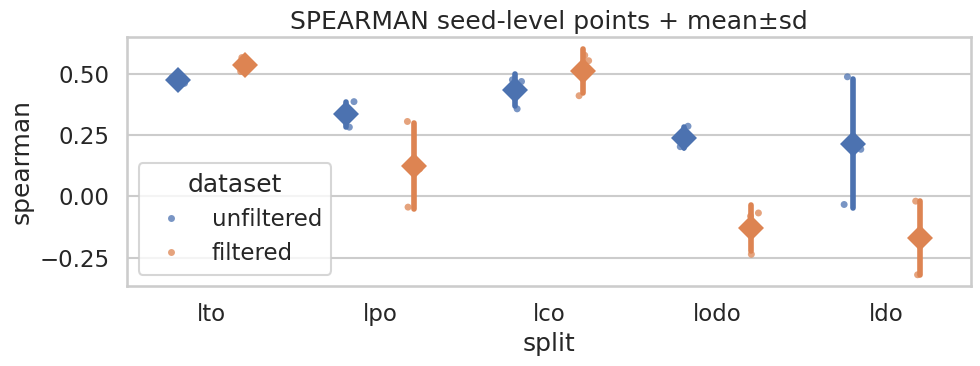

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- load ----
csv_path = "/content/drive/MyDrive/matchmaker_runs/matchmaker_outputs_20260327_011726/results/per_split_seed_metrics.csv"  # change if needed
df = pd.read_csv(csv_path)

# Ordering for readability
split_order = ["lto", "lpo", "lco", "lodo", "ldo"]
df["split"] = pd.Categorical(df["split"], categories=split_order, ordered=True)

metrics = ["mse", "spearman", "pearson", "auc", "auprc", "f1"]

# ---- aggregate ----
agg = (
    df.groupby(["dataset", "split"])[metrics]
      .agg(["mean", "std"])
      .reset_index()
)
agg.columns = ["dataset", "split"] + [f"{m}_{s}" for m in metrics for s in ["mean", "std"]]

# ---- 1) bar charts mean±std ----
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]
    # build plotting frame
    sub = agg[["dataset", "split", f"{m}_mean", f"{m}_std"]].copy()
    # draw bars manually with error bars
    for j, ds in enumerate(sorted(sub["dataset"].unique())):
        ds_sub = sub[sub["dataset"] == ds].sort_values("split")
        x = np.arange(len(ds_sub)) + (j - 0.5) * 0.35
        ax.bar(x, ds_sub[f"{m}_mean"], width=0.35, label=ds if i == 0 else None, alpha=0.8)
        ax.errorbar(
            x, ds_sub[f"{m}_mean"], yerr=ds_sub[f"{m}_std"],
            fmt="none", capsize=3, color="black", lw=1
        )

    ax.set_title(m.upper())
    ax.set_xticks(np.arange(len(split_order)))
    ax.set_xticklabels(split_order)
    if m == "mse":
        ax.set_ylabel("lower is better")
    else:
        ax.set_ylabel("higher is better")

axes[0].legend(title="dataset")
plt.tight_layout()
plt.show()

# ---- 2) heatmap of means ----
# choose one dataset at a time for clean reading
for ds in sorted(df["dataset"].unique()):
    mat = (
        df[df["dataset"] == ds]
        .groupby("split")[metrics]
        .mean()
        .reindex(split_order)
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Mean metrics by split ({ds})")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ---- 3) seed-level spread (example with AUC/F1) ----
for m in ["auc", "f1", "spearman"]:
    plt.figure(figsize=(10, 4))
    sns.stripplot(data=df, x="split", y=m, hue="dataset", dodge=True, alpha=0.75)
    sns.pointplot(
        data=df, x="split", y=m, hue="dataset", dodge=0.4, errorbar="sd",
        markers="D", linestyles="", legend=False
    )
    plt.title(f"{m.upper()} seed-level points + mean±sd")
    plt.tight_layout()
    plt.show()

## Troubleshooting

- **GitHub:** Set `GIT_REPO_URL` / `GIT_BRANCH` in the **Load codebase** cell. Private repo: clone via `https://TOKEN@github.com/org/repo.git` or Colab user secrets — see [GitHub docs](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token).
- **Layout:** Repo must expose `ens_492/main.py`; the checkout cell selects that folder automatically.
- **Legacy zip:** Only if you refuse git — set `PROJECT_SOURCE = "drive_zip"` and confirm `DRIVE_ZIP_PATH` after mounting Drive.
- **OOM:** Reduce `BATCH_SIZE` or lower `--batch-size`.
- **Raw CSV:** `RAW_CSV` in knobs cell — upload matching file under `data/`.
- **Older training recipe:** `NORM = 'tanh_norm'` and `WEIGHT_MODE = 'log'` before Step C/D.

Then **Run all** (after configuring `GIT_REPO_URL`).
